 ## X post generator using Iterative workflow of langgraph

Here, we will first generate a post using the given topic with the help of an LLM and then using another LLM, we will evaluate that post, and then if the evaluation is bad, we will send it to the 3rd LLM with feedback to optimize the post, then the process repeats in a loop, until the evaluator is satisfied. Now, after this the final post is generated as output.

### Lets Begin

Lets import all the necessary modules first

In [51]:
from langgraph.graph import StateGraph, START, END 
from typing import TypedDict, Annotated, Literal
from dotenv import load_dotenv
load_dotenv()
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage

Now, since we have 3 tasks, then we need to smartly choose the LLMs which are good at them relatively.



In [52]:
generator_llm = ChatOpenAI(model='gpt-4o-mini')
evaluator_llm = ChatOpenAI(model='gpt-4o') 
optimizer_llm = ChatOpenAI(model = 'gpt-4o-mini')

For evaluating the tweet, we need structured evaluator right, lets make a schema with the judgement metrics that will be used to evaluate the tweet.

In [53]:
from pydantic import BaseModel, Field 
class TweetEvaluation(BaseModel):
    evaluation: Literal['approved', 'needs_improvement'] = Field(description='Final evaluation result.')
    feedback: str = Field(description="feedback for the tweet")

#Now lets create the structured evaluator llm
structured_evaluator_llm = evaluator_llm.with_structured_output(TweetEvaluation)

Lets define the state for the graph

In [54]:
import operator

class TweetState(TypedDict):
    
    #Add the inputs
    topic: str

    #add the tweet generated
    tweet: str 

    #The evaluation response from the evaluator
    #This is the deciding factor to whether to post it or not etc
    evaluation : Literal["approved", "needs_improvement"]
    #ALong with it we need a string feedback also
    feedback: str

    #Now this is to track how many times the feedback loop is running
    iteration: int

    #To avoid running it indefinitely, we set a limit
    max_iteration: int

    #Lets add one more attribute to save all the iterations of the tweets generated also
    #also, here since this is a list, we need to use reducer, so that graph appends the data here not replace
    tweet_history: Annotated[list[str], operator.add ]

    #similarly we can save the feedbacks also
    feedback_history: Annotated[list[str], operator.add]


Now lets build the nodes required for the graph

In [55]:
def generate_tweet(State: TweetState):

    #Define the prompt
    messages = [
        SystemMessage(content="You are a funny and clever twitter/X/ influencer."),
        HumanMessage(content=f""" 
            Write a short , original and hilarious tweet on the topic: "{State['topic']}".capitalize

            Rules:
            - Do not use question-answer format.
            - Max 280 characters.
            - Use observational humor, irony, sarcasm, or cultural references.
            - Think in meme logic, punchlines, or relatable takes.
            - Use simple, day to day english
""" )
    ]
    # Send to the generator llm
    response = generator_llm.invoke(messages).content

    #Return the response, also add it to the history, so send it in the list format
    return {'tweet': response, 'tweet_history': [response]}


def evaluate_tweet(state: TweetState):

    # prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
]

    response = structured_evaluator_llm.invoke(messages)

    return {'evaluation':response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}

#now define the node to optimize the tweet
def optimize_tweet(state: TweetState):

    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    response = optimizer_llm.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'tweet': response, 'iteration': iteration, 'tweet_history': [response]}

Now, the create conditional edges, we need a router function, which obviously just outputs the name of the node which should be executed next.

OR we can implement the routing function to output some specific keywords, then later while adding that in the graph, we can then put where to route based on the keyword which is given as output here.

Let's use the keywords : "approved" and "Needs_improvement" for now.

In [56]:
def route_evaluation(State: TweetState):
    if State['evaluation'] == 'approved' or State['iteration'] >= State['max_iteration']:
        return "Approved"
    else:
        return "Needs_Improvement"

Lets build the graph


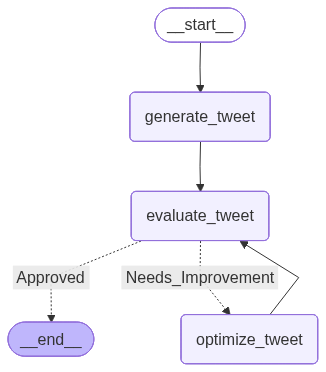

In [57]:
graph = StateGraph(TweetState)

#Add the nodes to the graph
graph.add_node('generate_tweet', generate_tweet)
graph.add_node('evaluate_tweet', evaluate_tweet)
graph.add_node('optimize_tweet', optimize_tweet)

#Now add the edges
graph.add_edge(START, 'generate_tweet')
graph.add_edge('generate_tweet', 'evaluate_tweet' )

#Now lets add the routing
#Now here we define where to route based on the keyword
graph.add_conditional_edges('evaluate_tweet', \
    route_evaluation, {'Approved': END, "Needs_Improvement": 'optimize_tweet'})

#Now, we need to connect this optimize tweet, back to evaluate tweet for evaluation after optimizing
graph.add_edge('optimize_tweet','evaluate_tweet')
#Thats it now the loop is created

#Lets compile the graph and see how it looks like
workflow = graph.compile()

workflow

Now lets test the workflow

In [61]:
initial_state = {
    'topic': "China democracy",
    'iteration': 1,
    'max_iteration': 5
}

final_state= workflow.invoke(initial_state)
final_state

{'topic': 'China democracy',
 'tweet': 'China’s democracy is like a buffet labeled “freedom” where every dish is mysteriously bland. You think you’re getting variety, but it’s all just “just kidding!” 🍽️🥡 #DemocracyDeluxe #WhySoBland',
 'evaluation': 'needs_improvement',
 'feedback': "The tweet critiques China's version of democracy with a metaphor comparing it to a bland buffet, which is moderately original but treads familiar ground in political humor about China. While the metaphor attempts humor, it lacks the sharpness that provokes a genuine laugh. The phrasing is somewhat awkward and long-winded, making it less scroll-stopping. Though the tweet is under 280 characters, it feels closer to a setup-punchline format, limiting its virality potential. Properly reworking the metaphor to be sharper and more concise could improve its impact.",
 'iteration': 5,
 'max_iteration': 5,
 'tweet_history': ['China democracy is like a buffet where every dish is labeled “surprise!” You think you’re